In [1]:
import tensorflow as tf

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import TextVectorization,Input,Dense,Embedding,GlobalMaxPooling1D,Conv1D,MaxPooling1D
from tensorflow.keras.models import Model

In [3]:
!wget -nc https://lazyprogrammer.me/course_files/spam.csv

--2025-03-24 14:08:26--  https://lazyprogrammer.me/course_files/spam.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 172.67.213.166, 104.21.23.210, 2606:4700:3031::6815:17d2, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 503663 (492K) [text/csv]
Saving to: ‘spam.csv’

spam.csv            100%[===================>] 491.86K  --.-KB/s    in 0.1s    

2025-03-24 14:08:27 (4.77 MB/s) - ‘spam.csv’ saved [503663/503663]



In [4]:
df = pd.read_csv('spam.csv',encoding='ISO-8859-1')

In [6]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
!head spam.csv

v1,v2,,,
ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",,,
ham,Ok lar... Joking wif u oni...,,,
spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,,,
ham,U dun say so early hor... U c already then say...,,,
ham,"Nah I don't think he goes to usf, he lives around here though",,,
spam,"FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, �1.50 to rcv",,,
ham,Even my brother is not like to speak with me. They treat me like aids patent.,,,
ham,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune,,,
spam,WINNER!! As a valued network customer you have been selected to receivea �900 prize reward! To claim call 09061701461. Claim 

In [8]:
df = df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.columns = ['labels','data']
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
df['b_labels'] = df['labels'].map({'ham':0,'spam':1})
df.head()

,labels,data,b_labels
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [11]:
Y = df['b_labels'].values
Y

array([0, 0, 1, ..., 0, 0, 0])

In [12]:
df_train,df_test,Ytrain,Ytest = train_test_split(
    df['data'],Y,test_size=0.33)

In [13]:
# create tf datasets
train_ds = tf.data.Dataset.from_tensor_slices((df_train.values,Ytrain))
test_ds = tf.data.Dataset.from_tensor_slices((df_test.values,Ytest))

In [14]:
# Convert sentences to sequences
MAX_VOCAB_SIZE = 20_000
vectorization = TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,)
vectorization.adapt(train_ds.map(lambda x,y:x))

In [15]:
# shuffle and batch the dataset
train_ds = train_ds.shuffle(10000).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

In [16]:
V = len(vectorization.get_vocabulary())
V

7666

In [18]:
input_sequences_train = vectorization(df_train.values)
input_sequences_test = vectorization(df_test.values)

In [19]:
input_sequences_train.shape

TensorShape([3733, 171])

In [20]:
inputs_sequences_test.shape

TensorShape([1839, 115])

In [21]:
T = input_sequences_train.shape[1]
T

171

In [22]:
vectorization2 = TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_sequence_length=T,
    vocabulary=vectorization.get_vocabulary())


In [23]:
# Create the model

D = 20

i = Input(shape=(1,),dtype=tf.string)
x = vectorization2(i)
x = Embedding(V,D)(x)
x = Conv1D(32,3,activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(64,3,activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(128,3,activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1,activation='sigmoid')(x)

model = Model(i,x)

In [24]:
#Compile and fit
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

r = model.fit(train_ds,validation_data=test_ds,epochs=5)

Epoch 1/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8248 - loss: 0.4536 - val_accuracy: 0.9260 - val_loss: 0.2341
Epoch 2/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9383 - loss: 0.1538 - val_accuracy: 0.9723 - val_loss: 0.0869
Epoch 3/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9922 - loss: 0.0247 - val_accuracy: 0.9804 - val_loss: 0.0607
Epoch 4/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9973 - loss: 0.0077 - val_accuracy: 0.9810 - val_loss: 0.0660
Epoch 5/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9826 - val_loss: 0.0704


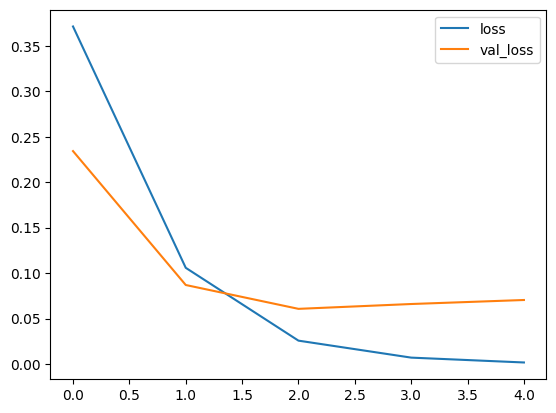

In [25]:
plt.plot(r.history['loss'],label='loss')
plt.plot(r.history['val_loss'],label='val_loss')
plt.legend()

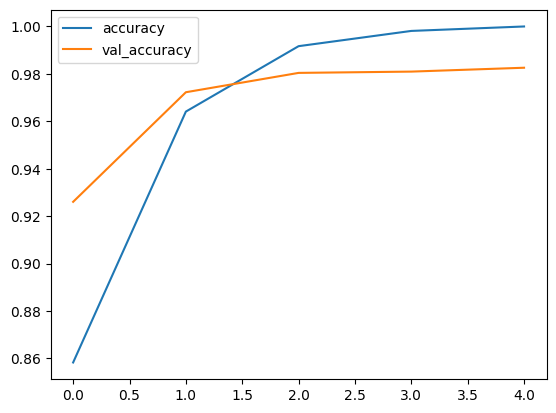

In [26]:
plt.plot(r.history['accuracy'],label='accuracy')
plt.plot(r.history['val_accuracy'],label='val_accuracy')
plt.legend()

<Axes: >

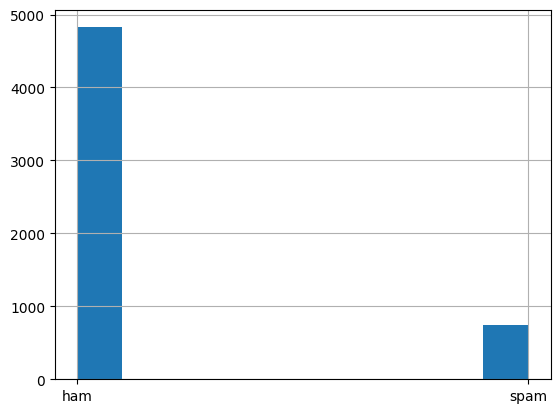

In [27]:
df['labels'].hist()

In [28]:
from sklearn.metrics import f1_score
f1_score(Ytrain,model.predict(df_train.values)>0.5)

117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


1.0

In [29]:
f1_score(Ytest,model.predict(df_test.values)>0.5)

58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


0.9313304721030042

----

In [35]:
input_sequences_train = vectorization(df_train.values)
input_sequences_test = vectorization(df_test.values)

In [36]:
# create tf datasets
train_ds = tf.data.Dataset.from_tensor_slices((input_sequences_train,Ytrain))
test_ds = tf.data.Dataset.from_tensor_slices((input_sequences_test,Ytest))

In [41]:
# Apply vectorization2 to both train and test data
input_sequences_train = vectorization2(df_train.values)
input_sequences_test = vectorization2(df_test.values)

# create tf datasets
train_ds = tf.data.Dataset.from_tensor_slices((input_sequences_train,Ytrain))
test_ds = tf.data.Dataset.from_tensor_slices((input_sequences_test,Ytest))

In [42]:
# shuffle and batch the dataset
train_ds = train_ds.shuffle(10000).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

In [43]:
# Create the model

D = 20

i = Input(shape=(T,))
x = Embedding(V,D)(i)
x = Conv1D(32,3,activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(64,3,activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(128,3,activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1,activation='sigmoid')(x)

model2 = Model(i,x)

In [44]:
#Compile and fit
model2.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

r2 = model2.fit(train_ds,validation_data=test_ds,epochs=5)

Epoch 1/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8643 - loss: 0.4601 - val_accuracy: 0.8706 - val_loss: 0.2535
Epoch 2/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9285 - loss: 0.1547 - val_accuracy: 0.9766 - val_loss: 0.0845
Epoch 3/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9953 - loss: 0.0195 - val_accuracy: 0.9782 - val_loss: 0.0948
Epoch 4/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9984 - loss: 0.0096 - val_accuracy: 0.9810 - val_loss: 0.0884
Epoch 5/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9999 - loss: 0.0018 - val_accuracy: 0.9815 - val_loss: 0.0955
